In [1]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.preprocessing import detrend_light_curve

df_flux_data = pd.read_csv("../data/processed/clean_flux.csv")
X = df_flux_data.drop(columns=['id', 'class']).values
y = df_flux_data['class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply Detrending (Removing the stellar noise)
print("Applying Savitzky-Golay detrending... (This will take a minute)")
X_train = np.array([detrend_light_curve(row) for row in X_train])
X_test = np.array([detrend_light_curve(row) for row in X_test])

# Feature Scaling (Z-Score Normalization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Conversion to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create DataLoader
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

print("DataLoaders are ready with Detrended and Scaled data.")

Applying Savitzky-Golay detrending... (This will take a minute)
DataLoaders are ready with Detrended and Scaled data.


### Detrending Effects on Model Performance (Before vs After)

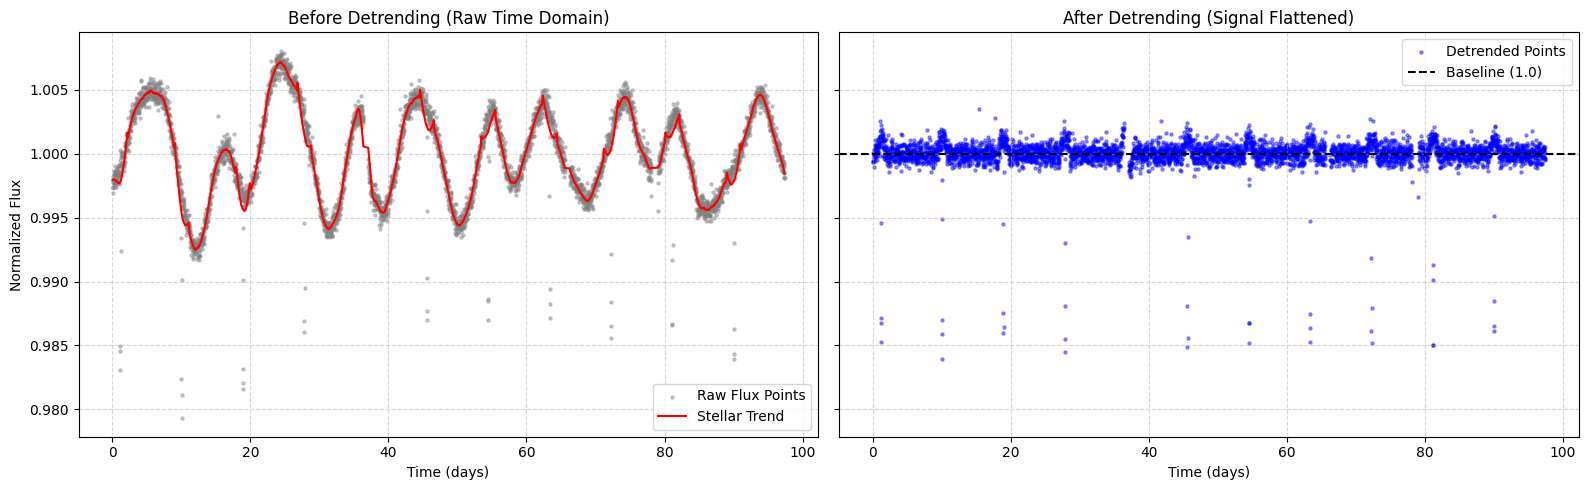

In [9]:
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

clean_flux = pd.read_csv("../data/processed/clean_flux.csv")
clean_time = pd.read_csv("../data/processed/clean_time.csv")

idx = clean_flux[clean_flux['class'] == 1].index[0]
raw_flux = clean_flux.drop(columns=['id', 'class']).iloc[idx].values
time_vals = clean_time.drop(columns=['id', 'class']).iloc[idx].values

trend = savgol_filter(raw_flux, window_length=101, polyorder=3)
detrended_flux = (raw_flux - trend) + 1.0

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)


# Graph 1: Raw data with a trend
axes[0].scatter(time_vals, raw_flux, s=5, color='gray', alpha=0.4, label='Raw Flux Points')
axes[0].plot(time_vals, trend, color='red', linewidth=1.5, label='Stellar Trend')
axes[0].set_title('Before Detrending (Raw Time Domain)')
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Normalized Flux')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Graph 2: Cleared data
axes[1].scatter(time_vals, detrended_flux, s=5, color='blue', alpha=0.4, label='Detrended Points')
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Baseline (1.0)')
axes[1].set_title('After Detrending (Signal Flattened)')
axes[1].set_xlabel('Time (days)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

### Model version 3

In [ ]:
import torch.nn as nn

class Exoplanet1DCNN_v3(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv1d(1, 16, kernel_size=21, padding=10)
        self.bn1 = nn.BatchNorm1d(16)
        self.pool1 = nn.MaxPool1d(2)
        
        self.conv2 = nn.Conv1d(16, 32, kernel_size=21, padding=10)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(2)
        
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(32 * 1152, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.flatten(x)
        x = self.dropout(torch.relu(self.bn3(self.fc1(x))))
        x = self.sigmoid(self.fc2(x))
        return x

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model_1 = Exoplanet1DCNN_v3().to(device)

# Binary Cross Entropy Loss 
criterion = nn.BCELoss()

import torch.optim as optim
optimizer_1 = optim.Adam(model_1.parameters(), lr=0.001)
epochs = 30

for epoch in range(epochs):
    model_1.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device).view(-1, 1)

        # Forward pass 
        outputs = model_1(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass
        optimizer_1.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epochs {epoch+1}/{epochs} - Loss: {avg_loss}")

print("Training Finished ")

Device: cuda
Epochs 1/30 - Loss: 0.6853095502466768
Epochs 2/30 - Loss: 0.6882206290154844
Epochs 3/30 - Loss: 0.6863476295728941
Epochs 4/30 - Loss: 0.6870779741454769
Epochs 5/30 - Loss: 0.6818628456141498
Epochs 6/30 - Loss: 0.6823101003427763
Epochs 7/30 - Loss: 0.6858081318236686
Epochs 8/30 - Loss: 0.6829122602939606
Epochs 9/30 - Loss: 0.685053951031453
Epochs 10/30 - Loss: 0.6874572376947146
Epochs 11/30 - Loss: 0.6884811681670111
Epochs 12/30 - Loss: 0.6840541612457585
Epochs 13/30 - Loss: 0.6870245450251812
Epochs 14/30 - Loss: 0.6858317980895171
Epochs 15/30 - Loss: 0.6866984069347382
Epochs 16/30 - Loss: 0.6812856294013359
Epochs 17/30 - Loss: 0.6841342513625687
Epochs 18/30 - Loss: 0.6829457903230512
Epochs 19/30 - Loss: 0.6828563889941653
Epochs 20/30 - Loss: 0.6850818677528484
Epochs 21/30 - Loss: 0.6856021728064563
Epochs 22/30 - Loss: 0.6833239197731018
Epochs 23/30 - Loss: 0.6845549683313112
Epochs 24/30 - Loss: 0.6857625157446474
Epochs 25/30 - Loss: 0.68403962415617

Evaluating 1D-CNN on Test Data...

Deep Learning (1D-CNN) Classification Report:
              precision    recall  f1-score   support

         0.0       0.52      0.52      0.52       600
         1.0       0.51      0.51      0.51       580

    accuracy                           0.52      1180
   macro avg       0.52      0.52      0.52      1180
weighted avg       0.52      0.52      0.52      1180



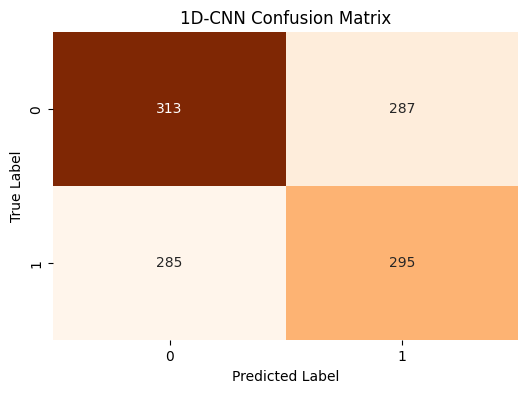

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


model_1.eval()

all_preds = []
all_targets = []

print("Evaluating 1D-CNN on Test Data...")
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        
        outputs = model_1(batch_X)
        
        preds = (outputs >= 0.5).float().cpu().numpy()
        targets = batch_y.numpy()
        
        all_preds.extend(preds)
        all_targets.extend(targets)

print("\nDeep Learning (1D-CNN) Classification Report:")
print(classification_report(all_targets, all_preds, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title("1D-CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()